# Day 4

In [37]:
%matplotlib inline

In [2]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import matplotlib
matplotlib.use("Agg")

In [3]:
import torch
import requests
import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image

from transformers import (
    AutoProcessor,
    AutoModelForZeroShotObjectDetection
)

from segment_anything import (
    sam_model_registry,
    SamPredictor
)

C:\Users\Admin\anaconda3\envs\ovs-thesis\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Using device: cuda
NVIDIA RTX PRO 4000 Blackwell


In [5]:
USE_STRUCTURE = True
USE_CLIP = True
USE_ADAPTIVE = True

In [6]:
model_id = "IDEA-Research/grounding-dino-tiny"

processor = AutoProcessor.from_pretrained(
    model_id
)

grounding_model = AutoModelForZeroShotObjectDetection.from_pretrained(
    model_id
).to(DEVICE)

print("GroundingDINO loaded")

Loading weights: 100%|█████████████████████████████████████████████████████████████| 990/990 [00:00<00:00, 9927.87it/s]


GroundingDINO loaded


In [7]:
SAM_CHECKPOINT = "../checkpoints/sam_vit_h_4b8939.pth"

sam = sam_model_registry["vit_h"](
    checkpoint=SAM_CHECKPOINT
)

sam.to(device=DEVICE)

predictor = SamPredictor(sam)

print("SAM loaded")

SAM loaded


In [74]:
class GroundedSAMPipeline:

    def __init__(
        self,
        processor,
        model,
        sam_predictor,
        device
    ):

        self.processor = processor
        self.model = model
        self.predictor = sam_predictor
        self.device = device

    def detect(
        self,
        image_pil,
        text_prompt,
        box_threshold=0.25,
        text_threshold=0.25
    ):

        inputs = self.processor(
            images=image_pil,
            text=text_prompt,
            return_tensors="pt"
        ).to(self.device)

        with torch.no_grad():

            outputs = self.model(**inputs)

        results = self.processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            threshold=box_threshold,
            text_threshold=text_threshold,
            target_sizes=[image_pil.size[::-1]]
        )

        result = results[0]

        return (
            result["boxes"].cpu().numpy(),
            result["scores"].cpu().numpy(),
            result["text_labels"]
        )

    def segment(
        self,
        image_np,
        boxes
    ):

        self.predictor.set_image(image_np)

        masks_list = []

        for box in boxes:

            mask, _, _ = self.predictor.predict(
                point_coords=None,
                point_labels=None,
                box=box.astype(np.float32),
                multimask_output=False
            )

            masks_list.append(mask[0])

        if len(masks_list) == 0:

            return np.array([])
        
        return np.stack(masks_list, axis=0)

    def run(
        self,
        image_pil,
        text_prompt,
        box_threshold=0.25
    ):

        boxes, scores, labels = self.detect(
            image_pil,
            text_prompt,
            box_threshold
        )

        image_np = np.array(
            image_pil.convert("RGB")
        )

        masks = self.segment(
            image_np,
            boxes
        )

        return {
            "image_np": image_np,
            "boxes": boxes,
            "scores": scores,
            "labels": labels,
            "masks": masks
        }

In [75]:
pipeline = GroundedSAMPipeline(
    processor,
    grounding_model,
    predictor,
    DEVICE
)

print("Pipeline ready")

Pipeline ready


In [76]:
image_url = "http://farm1.staticflickr.com/52/181543138_2b5352a951_z.jpg"

# http://farm1.staticflickr.com/52/181543138_2b5352a951_z.jpg
# http://farm1.staticflickr.com/26/100143183_3dc8653fa5_z.jpg

image_pil = Image.open(
    requests.get(
        image_url,
        stream=True
    ).raw
).convert("RGB")

print(image_pil.size)

(425, 640)


In [77]:
text_prompt = "person. laptop. cat. dog. traffic light."

result = pipeline.run(
    image_pil,
    text_prompt,
    box_threshold=0.25
)

print(f"Detected {len(result['labels'])} objects")

for label, score in zip(
    result["labels"],
    result["scores"]
):
    print(label, float(score))

Detected 18 objects
person 0.8678135871887207
person 0.8798992037773132
person 0.613670825958252
person 0.7454606890678406
traffic light 0.507236897945404
traffic light 0.4571547210216522
person 0.4147038459777832
dog 0.37558653950691223
person 0.46948301792144775
person 0.4086702764034271
person 0.3276982009410858
person 0.2798275351524353
person 0.36478111147880554
person 0.32919496297836304
dog 0.3331433832645416
person 0.3320758640766144
person 0.2951129674911499
dog 0.2720016539096832


In [78]:
semantic_scores = []

for score in result["scores"]:

    semantic_scores.append(
        float(score)
    )

print("Semantic scores extracted")
print(semantic_scores)

Semantic scores extracted
[0.8678135871887207, 0.8798992037773132, 0.613670825958252, 0.7454606890678406, 0.507236897945404, 0.4571547210216522, 0.4147038459777832, 0.37558653950691223, 0.46948301792144775, 0.4086702764034271, 0.3276982009410858, 0.2798275351524353, 0.36478111147880554, 0.32919496297836304, 0.3331433832645416, 0.3320758640766144, 0.2951129674911499, 0.2720016539096832]


In [79]:
import cv2
import numpy as np

def compute_structural_score(mask):

    # AREA CONSISTENCY
    area = np.sum(mask)

    normalized_area = min(
        area / 10000.0,
        1.0
    )

    # CONTOUR SMOOTHNESS
    contours, _ = cv2.findContours(
        mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    perimeter = 0

    if len(contours) > 0:

        perimeter = cv2.arcLength(
            contours[0],
            True
        )

    contour_score = min(
        perimeter / 1000.0,
        1.0
    )

    # EDGE COHERENCE
    edges = cv2.Canny(
        mask.astype(np.uint8) * 255,
        100,
        200
    )

    edge_density = (
        np.sum(edges > 0)
        /
        (mask.shape[0] * mask.shape[1])
    )

    edge_score = min(
        edge_density * 10,
        1.0
    )

    # FINAL STRUCTURAL SCORE
    structural_score = (
        0.4 * normalized_area
        +
        0.3 * contour_score
        +
        0.3 * edge_score
    )

    return float(structural_score)

In [80]:
structural_scores = []

for mask in result["masks"]:

    score = compute_structural_score(
        mask
    )

    structural_scores.append(score)

In [81]:
def compute_uncertainty(confidence):

    uncertainty = 1.0 - float(confidence)
    print(uncertainty)
    return uncertainty

In [82]:
import numpy as np

def softmax(x):

    e_x = np.exp(x - np.max(x))

    return e_x / e_x.sum()


def adaptive_weights(
    semantic_conf,
    structural_score,
    agreement_score
):

    semantic_uncertainty = compute_uncertainty(
        semantic_conf
    )

    adjusted_semantic = (
        semantic_conf
        *
        (1 - semantic_uncertainty)
    )

    scores = np.array([
        adjusted_semantic,
        structural_score,
        agreement_score
    ])

    weights = softmax(scores)

    return {
        "semantic_weight": float(weights[0]),
        "structural_weight": float(weights[1]),
        "agreement_weight": float(weights[2])
    }

In [83]:
import open_clip

In [84]:
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="openai"
)

tokenizer = open_clip.get_tokenizer(
    "ViT-B-32"
)

clip_model = clip_model.to(DEVICE)

print("CLIP loaded")

CLIP loaded


In [85]:
# Crop helper
def crop_mask_region(image_rgb, mask):

    ys, xs = np.where(mask > 0)

    if len(xs) == 0 or len(ys) == 0:
        return None

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    crop = image_rgb[y1:y2, x1:x2]

    return crop

In [86]:
#CLIP scoring

from PIL import Image

def compute_clip_score(crop, text):

    if crop is None:
        return 0.0

    image_pil = Image.fromarray(crop)

    image_input = clip_preprocess(
        image_pil
    ).unsqueeze(0).to(DEVICE)

    text_input = tokenizer(
        [text]
    ).to(DEVICE)

    with torch.no_grad():

        image_features = clip_model.encode_image(
            image_input
        )

        text_features = clip_model.encode_text(
            text_input
        )

        image_features /= image_features.norm(
            dim=-1,
            keepdim=True
        )

        text_features /= text_features.norm(
            dim=-1,
            keepdim=True
        )

        similarity = (
            image_features
            @
            text_features.T
        )

    return similarity.item()

In [87]:
def compute_clip_probabilities(
    crop,
    candidate_labels
):

    image_pil = Image.fromarray(crop)

    image_input = clip_preprocess(
        image_pil
    ).unsqueeze(0).to(DEVICE)

    text_input = tokenizer(
        candidate_labels
    ).to(DEVICE)

    with torch.no_grad():

        image_features = clip_model.encode_image(
            image_input
        )

        text_features = clip_model.encode_text(
            text_input
        )

        image_features /= image_features.norm(
            dim=-1,
            keepdim=True
        )

        text_features /= text_features.norm(
            dim=-1,
            keepdim=True
        )

        similarity = (
            100.0 *
            image_features
            @
            text_features.T
        )

        probs = similarity.softmax(
            dim=-1
        )

    return probs[0].cpu().numpy()

In [88]:
clip_scores = []

clip_labels = []

candidate_labels = [
    "person",
    "laptop",
    "bottle",
    "cat",
    "traffic light",
    "dog",
    "car"
]

for i, mask in enumerate(result["masks"]):

    crop = crop_mask_region(
        result["image_np"],
        mask
    )

    probs = compute_clip_probabilities(
        crop,
        candidate_labels
    )

    best_idx = probs.argmax().item()

    best_prob = probs[best_idx].item()

    clip_label = candidate_labels[best_idx]

    clip_scores.append(best_prob)

    clip_labels.append(clip_label)

    print(
        f"[{i+1}] "
        f"CLIP={clip_label} "
        f"({best_prob:.3f})"
    )

[1] CLIP=person (0.513)
[2] CLIP=traffic light (0.796)
[3] CLIP=person (0.320)
[4] CLIP=bottle (0.330)
[5] CLIP=laptop (0.368)
[6] CLIP=bottle (0.379)
[7] CLIP=person (0.357)
[8] CLIP=dog (0.924)
[9] CLIP=person (0.334)
[10] CLIP=person (0.390)
[11] CLIP=person (0.465)
[12] CLIP=person (0.355)
[13] CLIP=traffic light (0.328)
[14] CLIP=person (0.458)
[15] CLIP=dog (0.859)
[16] CLIP=person (0.396)
[17] CLIP=person (0.357)
[18] CLIP=dog (0.931)


In [89]:
clip_agreements = []

for i, clip_score in enumerate(clip_scores):

    if clip_score > 0.8:

        agreement = 1.0

    elif clip_score > 0.5:

        agreement = 0.7

    else:

        agreement = 0.3

    clip_agreements.append(agreement)

print("CLIP agreements:")
print(clip_agreements)

CLIP agreements:
[0.7, 0.7, 0.3, 0.3, 0.3, 0.3, 0.3, 1.0, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 1.0, 0.3, 0.3, 1.0]


In [90]:
from scipy.stats import entropy
import numpy as np

def confidence_entropy(scores):

    scores = np.array(scores)

    scores = scores / np.sum(scores)

    return entropy(scores)

In [91]:
def adaptive_structural_arbitration(

    semantic_conf,
    structural_score,
    agreement_score,
    clip_scores

):

    # ENTROPY-BASED RELIABILITY
    clip_entropy = confidence_entropy(
        clip_scores
    )

    # STRUCTURAL BOOST UNDER HIGH SEMANTIC UNCERTAINTY
    if clip_entropy > 0.8:

        structural_score *= 1.2

    # COMPUTE DYNAMIC WEIGHTS
    weights = adaptive_weights(
        semantic_conf,
        structural_score,
        agreement_score
    )

    # FINAL ARBITRATION
    final_score = (

        weights["semantic_weight"]
        * semantic_conf

        +

        weights["structural_weight"]
        * structural_score

        +

        weights["agreement_weight"]
        * agreement_score
    )

    return {
        "final_score": float(final_score),
        "weights": weights,
        "entropy": float(clip_entropy)
    }

In [92]:
asam_results = []

for i, (
    semantic_conf,
    structural_score,
    agreement_score
) in enumerate(

    zip(
        semantic_scores,
        structural_scores,
        clip_agreements
    )
):

    clip_scores = [
        semantic_conf,
        agreement_score,
        structural_score
    ]

    result_item = adaptive_structural_arbitration(

        semantic_conf=semantic_conf,
        structural_score=structural_score,
        agreement_score=agreement_score,
        clip_scores=clip_scores
    )

    asam_results.append(result_item)

0.1321864128112793
0.12010079622268677
0.38632917404174805
0.2545393109321594
0.49276310205459595
0.5428452789783478
0.5852961540222168
0.6244134604930878
0.5305169820785522
0.5913297235965729
0.6723017990589142
0.7201724648475647
0.6352188885211945
0.670805037021637
0.6668566167354584
0.6679241359233856
0.7048870325088501
0.7279983460903168


In [93]:
for i, result_item in enumerate(asam_results):

    print(
        f"[{i+1}] "
        f"{result['labels'][i]:15} | "
        f"Final={result_item['final_score']:.3f} | "
        f"Entropy={result_item['entropy']:.3f} | "
        f"S={result_item['weights']['semantic_weight']:.2f} | "
        f"St={result_item['weights']['structural_weight']:.2f} | "
        f"A={result_item['weights']['agreement_weight']:.2f}"
    )

[1] person          | Final=0.681 | Entropy=1.026 | S=0.38 | St=0.26 | A=0.36
[2] person          | Final=0.746 | Entropy=1.078 | S=0.36 | St=0.31 | A=0.33
[3] person          | Final=0.350 | Entropy=0.798 | S=0.38 | St=0.27 | A=0.35
[4] person          | Final=0.530 | Entropy=1.025 | S=0.37 | St=0.35 | A=0.29
[5] traffic light   | Final=0.313 | Entropy=0.914 | S=0.34 | St=0.30 | A=0.36
[6] traffic light   | Final=0.286 | Entropy=0.886 | S=0.34 | St=0.29 | A=0.37
[7] person          | Final=0.276 | Entropy=0.939 | S=0.33 | St=0.30 | A=0.37
[8] dog             | Final=0.667 | Entropy=0.865 | S=0.23 | St=0.24 | A=0.53
[9] person          | Final=0.295 | Entropy=0.911 | S=0.34 | St=0.30 | A=0.37
[10] person          | Final=0.256 | Entropy=0.788 | S=0.33 | St=0.29 | A=0.38
[11] person          | Final=0.229 | Entropy=0.819 | S=0.32 | St=0.29 | A=0.39
[12] person          | Final=0.218 | Entropy=0.893 | S=0.31 | St=0.30 | A=0.39
[13] person          | Final=0.240 | Entropy=0.797 | S=0.33 |

In [94]:
filtered_masks = []

filtered_labels = []

filtered_scores = []

for i, result_item in enumerate(asam_results):

    final_score = result_item["final_score"]

    entropy = result_item["entropy"]

    adaptive_threshold = (
        0.45
        +
        entropy * 0.05
    )

    if final_score > adaptive_threshold:

        filtered_masks.append(
            result["masks"][i]
        )

        filtered_labels.append(
            result["labels"][i]
        )

        filtered_scores.append(
            final_score
        )

In [95]:
import numpy as np

def compute_mask_iou(mask1, mask2):

    intersection = np.logical_and(
        mask1,
        mask2
    ).sum()

    union = np.logical_or(
        mask1,
        mask2
    ).sum()

    if union == 0:
        return 0.0

    return intersection / union

In [96]:
def agglomerative_merge(

    masks,
    labels,
    scores,
    iou_threshold=0.3

):

    merged_masks = []

    merged_labels = []

    merged_scores = []

    used = set()

    for i in range(len(masks)):

        if i in used:
            continue

        current_mask = masks[i].copy()

        current_label = labels[i]

        current_score = scores[i]

        used.add(i)

        for j in range(i + 1, len(masks)):

            if j in used:
                continue

            # Merge ONLY same class
            if labels[j] != current_label:
                continue

            iou = compute_mask_iou(
                current_mask,
                masks[j]
            )

            if iou > iou_threshold:

                current_mask = np.logical_or(
                    current_mask,
                    masks[j]
                )

                current_score = max(
                    current_score,
                    scores[j]
                )

                used.add(j)

        merged_masks.append(
            current_mask
        )

        merged_labels.append(
            current_label
        )

        merged_scores.append(
            current_score
        )

    return (
        merged_masks,
        merged_labels,
        merged_scores
    )

In [97]:
merged_masks, merged_labels, merged_scores = agglomerative_merge(

    filtered_masks,
    filtered_labels,
    filtered_scores,

    iou_threshold=0.3
)

print(
    f"Before merging: {len(filtered_masks)}"
)

print(
    f"After merging: {len(merged_masks)}"
)

Before merging: 6
After merging: 4


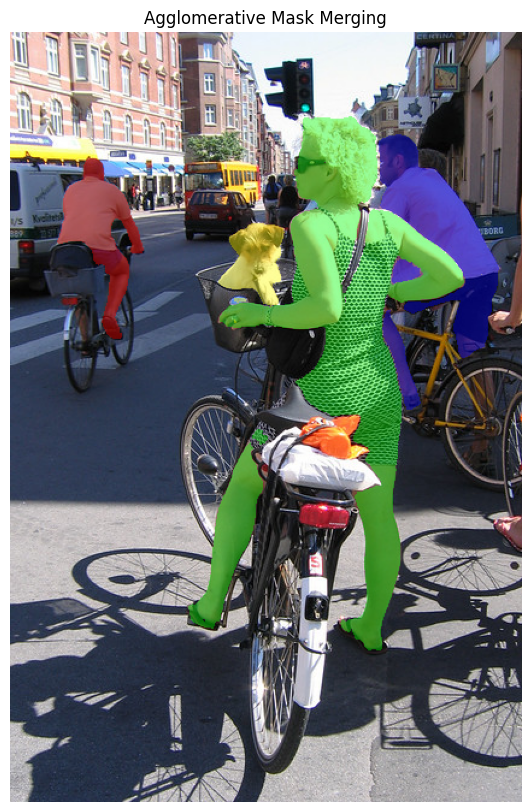

In [98]:
import matplotlib.pyplot as plt

overlay = result["image_np"].copy()

colors = [
    [255, 0, 0],
    [0, 255, 0],
    [0, 0, 255],
    [255, 255, 0]
]

for i, mask in enumerate(merged_masks):

    overlay[mask > 0] = (
        0.6 * overlay[mask > 0]
        +
        0.4 * np.array(
            colors[i % len(colors)]
        )
    )

plt.figure(figsize=(10,10))

plt.imshow(
    overlay.astype(np.uint8)
)

plt.title(
    "Agglomerative Mask Merging"
)

plt.axis("off")

plt.show()

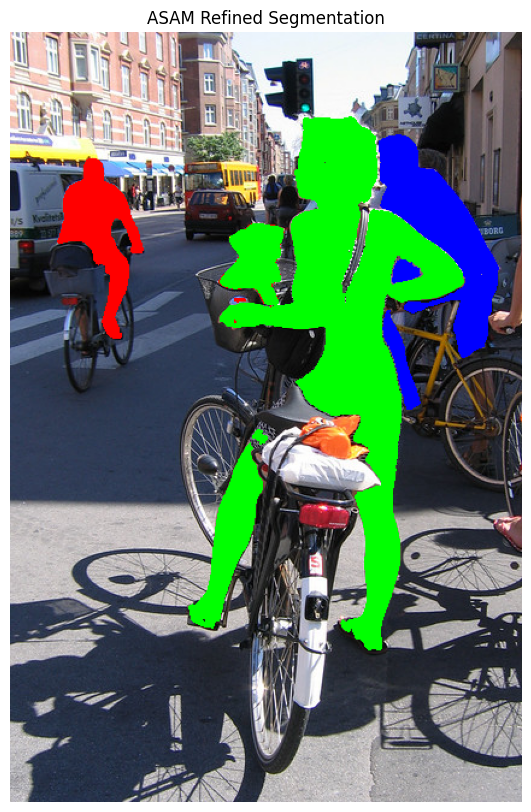

In [99]:
import matplotlib.pyplot as plt
import numpy as np

overlay = result["image_np"].copy()

colors = [
    [255, 0, 0],
    [0, 255, 0],
    [0, 0, 255],
    [255, 255, 0]
]

for i, mask in enumerate(filtered_masks):

    overlay[mask > 0] = colors[
        i % len(colors)
    ]

plt.figure(figsize=(10,10))

plt.imshow(overlay)

plt.title(
    "ASAM Refined Segmentation"
)

plt.axis("off")

plt.show()

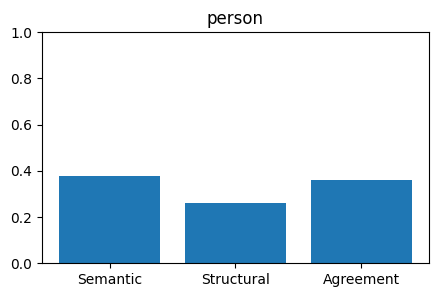

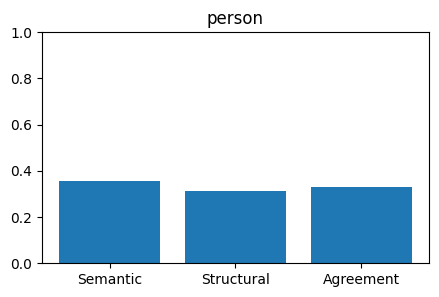

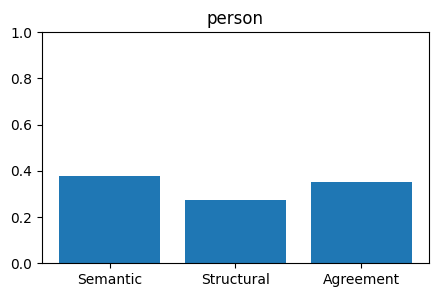

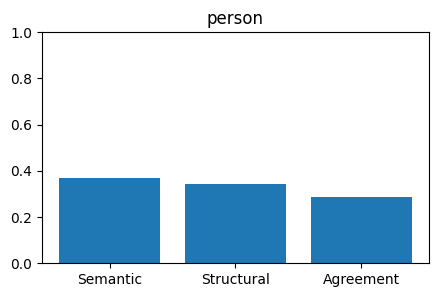

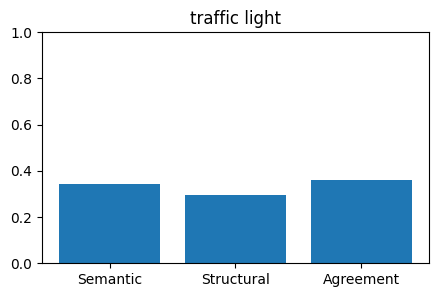

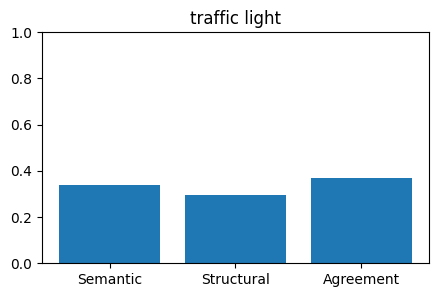

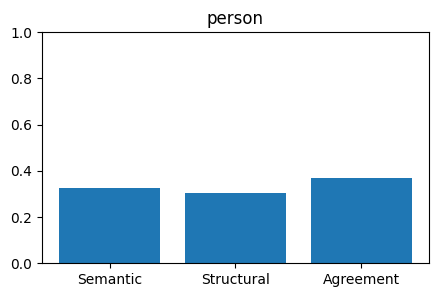

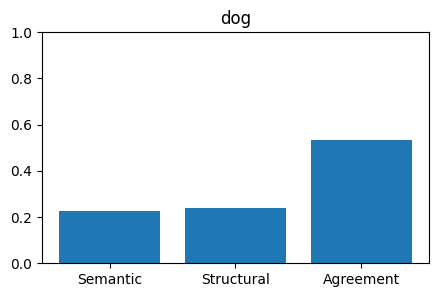

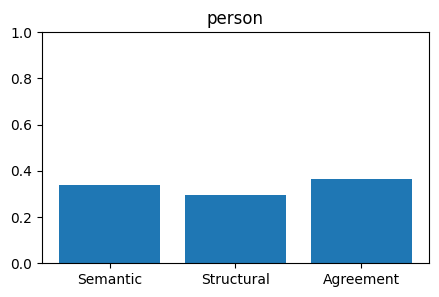

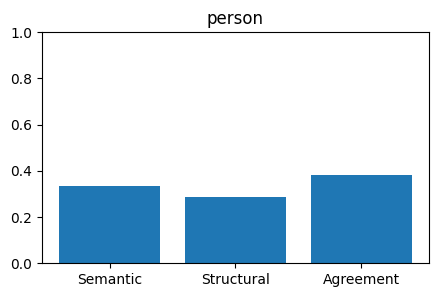

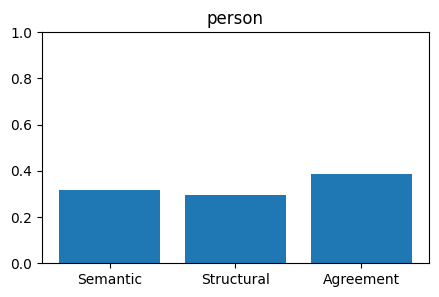

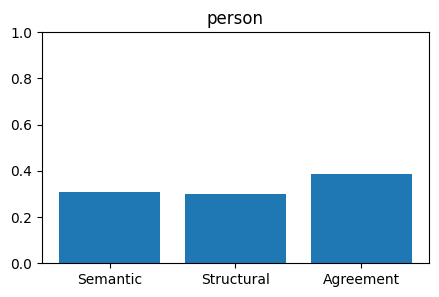

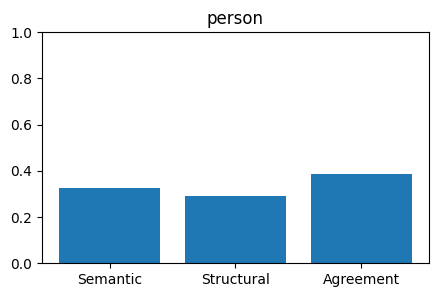

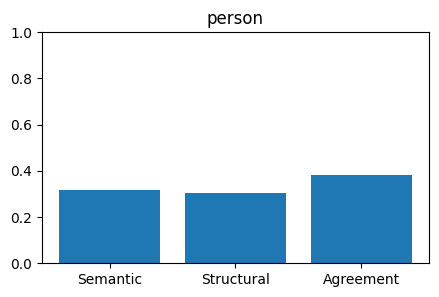

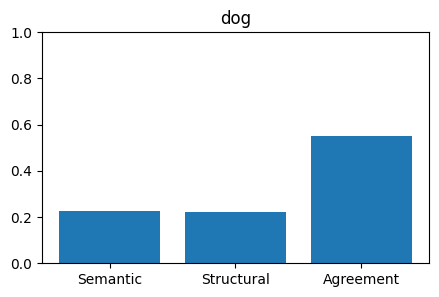

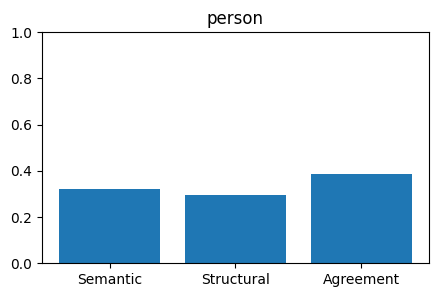

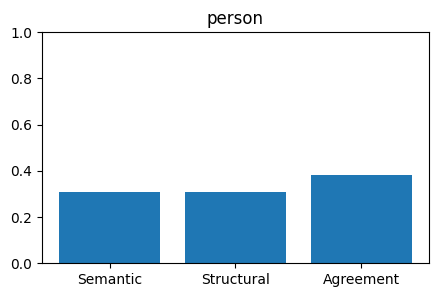

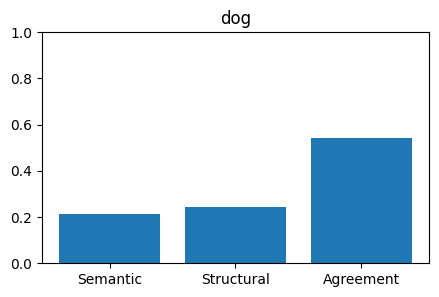

In [100]:
for i, result_item in enumerate(asam_results):

    plt.figure(figsize=(5,3))

    labels = [
        "Semantic",
        "Structural",
        "Agreement"
    ]

    values = [
        result_item["weights"]["semantic_weight"],
        result_item["weights"]["structural_weight"],
        result_item["weights"]["agreement_weight"]
    ]

    plt.bar(labels, values)

    plt.ylim(0,1)

    plt.title(
        f"{result['labels'][i]}"
    )

    plt.show()

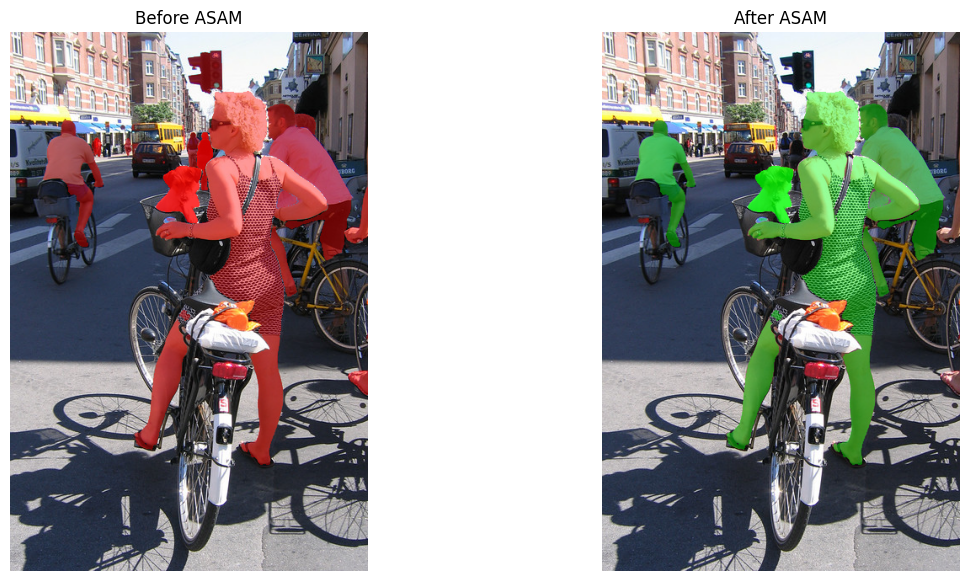

In [101]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(14,7)
)

# BEFORE
before = result["image_np"].copy()

for mask in result["masks"]:

    # before[mask > 0] = [255,0,0]
    before[mask > 0] = (
    0.6 * before[mask > 0]
    +
    0.4 * np.array([255,0,0]))

ax[0].imshow(before)

ax[0].set_title(
    "Before ASAM"
)

ax[0].axis("off")

# AFTER
after = result["image_np"].copy()

for mask in filtered_masks:

    # after[mask > 0] = [0,255,0]
    after[mask > 0] = (
    0.6 * after[mask > 0]
    +
    0.4 * np.array([0,255,0]))

ax[1].imshow(after)

ax[1].set_title(
    "After ASAM"
)

ax[1].axis("off")

plt.show()

In [102]:
print("========== ASAM Evaluation ==========")

print(f"Raw detections: {len(result['labels'])}")

print(f"After ASAM filtering: {len(filtered_masks)}")

print(f"After agglomerative merging: {len(merged_masks)}")

avg_score = np.mean(filtered_scores)

print(f"Average final score: {avg_score:.3f}")

========== ASAM Evaluation ==========
Raw detections: 18
After ASAM filtering: 6
After agglomerative merging: 4
Average final score: 0.653


In [103]:
static_scores = []

for i, (
    semantic_conf,
    structural_score,
    agreement_score
) in enumerate(

    zip(
        semantic_scores,
        structural_scores,
        clip_agreements
    )
):

    static_score = (
        semantic_conf
        +
        structural_score
        +
        agreement_score
    ) / 3

    static_scores.append(
        static_score
    )

avg_static = np.mean(static_scores)

avg_asam = np.mean(filtered_scores)

print("========== Comparison ==========")

print(
    f"Static Fusion Avg: {avg_static:.3f}"
)

print(
    f"ASAM Avg: {avg_asam:.3f}"
)

========== Comparison ==========
Static Fusion Avg: 0.350
ASAM Avg: 0.653
